# Кластеризация методом `K-means` для выделения групп объектов

В этой задаче будет рассмотрен метод кластеризации <code>K-means</code> для решения непосредственно задачи кластеризации — задачи выделения схожих структур в данных. Работать будем с известным набором данных <a href="http://yann.lecun.com/exdb/mnist/"><code>MNIST</code></a>.

Загрузим набор данных. Будем использовать только тестовую часть оригинального набора, чтобы сократить время обучения моделей.

In [ ]:
from keras.datasets import mnist
import warnings
warnings.filterwarnings("ignore")

(_,_), (X, y) = mnist.load_data()

Пример вывода нескольких объектов и соответствующих меток классов:

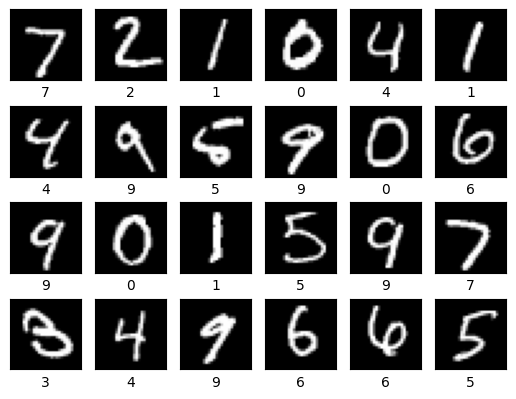

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(X[i], cmap='gray')
    axi.set(xticks=[], yticks=[])
    axi.set_xlabel(y[i],
                   color='black')

Введите <code>.shape</code> полученного набора данных

In [ ]:
X.shape, y.shape

((10000, 28, 28), (10000,))

In [ ]:
X = X.reshape((X.shape[0], -1))
X.shape

(10000, 784)

При помощи <code>train_test_split</code> разобейте полученный набор данных на тренеровочную и тестовую выборки с параметрами, указанными в вашем варианте.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 65)

Давайте, раз речь идет об известном наборе данных, заставим <code>K-means</code> искать $10$ групп объектов.

«Распрямите» изображения и обучите алгоритм <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html"><code>KMeans</code></a> с параметрами, указанными в вашем задании.

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 10, random_state = 65)
kmeans.fit(X_train, y_train)

KMeans(n_clusters=10, random_state=65)

Определите чило элементов, отнесенных к кластеру, указанному в вашем задании

In [ ]:
len(kmeans.labels_[kmeans.labels_ == 8])

752

Постройте изображения, соответствующие центроидам полученных кластеров. Для этого `reshape`ните координаты центроидов до размера $28 \times 28$ и постройте полученную матрицу, например, в черно-белых оттенках.



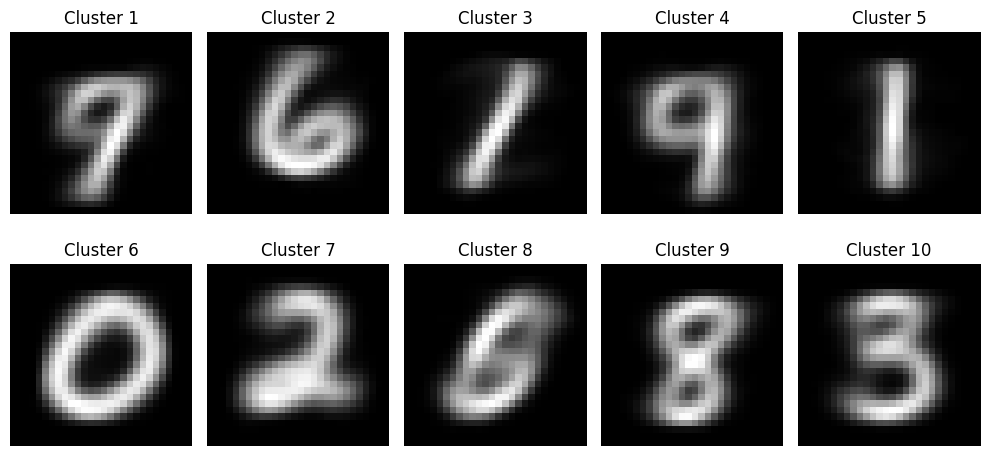

In [ ]:
import matplotlib.pyplot as plt

centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i, centroid in enumerate(centroids):

    centroid_image = centroid.reshape(28, 28)

    axes[i].imshow(centroid_image, cmap='gray')
    axes[i].set_title(f'Cluster {i + 1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Можно заметить, что получившиеся картинки весьма походят на рукописные цифры. Впрочем, кластеризация прошла не без накладок. Предположите, какие цифры могут быть перепутаны и каких не хватает.

Так как получившиеся кластеры ничего не знают о природе кластеризумых объектов, метки кластеров могут отличаться от «разумных меток». Восстановите правильные метки, используя следующие соображения: кластеру присваивается метка тех цифр, представителей которых в кластере большинство. Действительно ли это помогло восстановить справедливость?

Введите полученные метки кластеров после преобразования и сравните с ранее построенными изображениями на основе центроидов. Подтверждаются ли ваши догадки фактами?

In [ ]:
import pandas as pd

labels_compare = pd.DataFrame({'kmeans_label' : kmeans.labels_, 'correct_label' : y_train})
labels_compare.sample(5)

,kmeans_label,correct_label
2575,2,1
5659,3,5
6591,3,4
532,2,1
1825,2,1


In [ ]:
correct_labels = labels_compare.groupby('kmeans_label').agg(pd.Series.mode).values.reshape((10,))
correct_labels


array([7, 6, 1, 4, 1, 0, 2, 5, 8, 3], dtype=uint8)

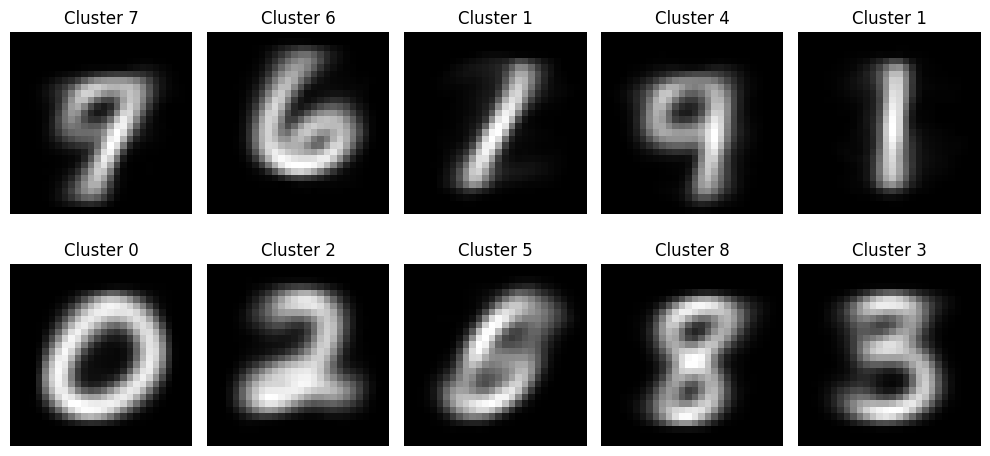

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i, centroid in enumerate(centroids):

    centroid_image = centroid.reshape(28, 28)

    axes[i].imshow(centroid_image, cmap='gray')
    axes[i].set_title(f'Cluster {correct_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Разумно оценить что-то вроде точности. Считая, что все объекты кластера имеют ту же метку, что и сам кластер, сравните эти метки с истинными метками. Вычислите <code>accuracy</code>. Рекомендуем использовать функцию <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html"><code>accuracy_score</code></a> из библиотеки <code>sklearn</code>.

In [ ]:
from sklearn.metrics import accuracy_score

true_kmean_labels = [correct_labels[i] for i in kmeans.labels_]
f"{accuracy_score(y_train, true_kmean_labels):.3f}"

'0.604'

При помощи метода <code>.predict()</code> произведите кластеризацию тестовых данных. Переименуйте метки предсказанных кластеров на основе полученного для тренировочного набора данных преобразования.

In [ ]:
pred = kmeans.predict(X_test)

In [ ]:
true_correct_labels = [correct_labels[i] for i in pred]
f"{accuracy_score(true_correct_labels, y_test):.3f}"

'0.590'

Постройте матрицу ошибок.

Text(95.72222222222221, 0.5, 'Actual')

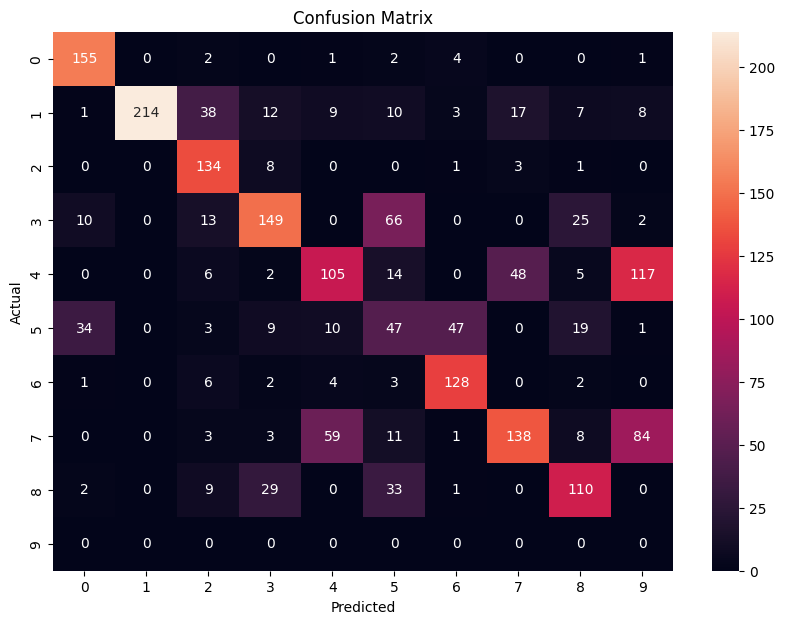

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_mat = confusion_matrix(true_correct_labels, y_test)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


С какой цифрой построенная модель чаще всего путала цифру, указанную в вашем варианте?

In [ ]:
# c 4

Интересно отметить, что мы построили классификатор на основе кластеризации при том, что никакими «правильными ответами» мы не пользовались (разве что для оценки).

А сколько кластеров кажется оптимальным количеством, если использовать каменистую осыпь? Постройте график каменистой осыпи для числа кластеров от $7$ до $16$. Можно ли уверенно определить оптимальное число кластеров?

In [ ]:
# список для хранения сумм квадратов расстояний от каждой точки до центра ее кластера
wcss = []

for i in range(7, 17):
    kmeans = KMeans(random_state = 65, n_clusters = i)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

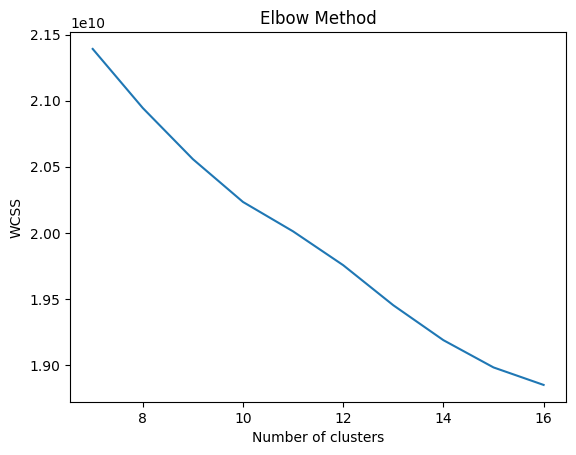

In [ ]:
plt.plot(range(7, 17), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

Все эти обучения черезчур уж долгие. Давайте сделаем «ход конем» и понизим размерность данных, пытаясь сохранять расстояния между объектами. Посмотрим, как это скажется на скорости и точности.

Преобразуйте <b>тренировочный набор</b> данных при помощи метода <a href="https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html"><code>TSNE</code></a> из библиотеки <code>sklearn</code>. Используйте параметры, указанные в вашем задании.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, init = 'pca', random_state = 65)
train_tsne = tsne.fit_transform(X_train)

Произведите кластеризацию полученного набора данных при помощи <code>KMeans</code> с параметрами, указанными в вашем задании. Аналогично проделанному раньше переназначьте метки кластеров на основе метки большинства объектов в рамках кластера. Оцените точность модели на <b>тренировочных данных</b>.

In [ ]:
kmeans = KMeans(n_clusters = 10, random_state = 65)
kmeans.fit(train_tsne)

KMeans(n_clusters=10, random_state=65)

In [ ]:
labels_compare = pd.DataFrame({'kmeans_label' : kmeans.labels_, 'correct_label' : y_train})
labels_compare.sample(5)

,kmeans_label,correct_label
7804,9,4
3264,7,2
2213,0,9
7946,0,7
1555,5,0


In [ ]:
correct_labels = labels_compare.groupby('kmeans_label').agg(lambda x: pd.Series.mode(x)[0]).values.reshape((10,))
correct_labels


array([7, 3, 6, 1, 5, 0, 9, 2, 8, 4], dtype=uint8)

In [ ]:
true_correct_labels = [correct_labels[i] for i in kmeans.labels_]
f"{accuracy_score(true_correct_labels, y_train):.3f}"

'0.835'

Проблема, однако, известна. `t-SNE` — метод, который не дает правила получения проекций многомерного пространства на, например, двумерное. Тем самым, при появлении новых данных, проекции придется искать заново.

В то же время, еще раз хочется подчеркнуть, как обучение без учителя позволило построить классификатор, который, как будто бы, является результатом решения задачи обучения с учителем.